In [13]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils import *
from utils_sofima import *
import numpy as np
import hyperspy.api as hs
import matplotlib.pyplot as plt
import copy
from importlib import reload
from EDX import *
from skimage import data, img_as_float, feature
import tensorstore as ts
from scipy.stats import pearsonr
from datetime import datetime
import warnings
import pickle
from datetime import datetime

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load haadf stack

In [14]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# load and preprocess
EXD_summed_unaligned, haadf_stack, _ = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True, haadf_last_frame=False)

print(haadf_stack.shape)
print(haadf_stack.max(),haadf_stack.dtype)

WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)
(100, 2048, 2048)
65535.0 float64


### Align based on the first 20 HAADf images 

In [15]:
sof_obj = get_alignment(haadf_stack, 
                  n_align = 20,
                  min_peak_ratio=1.1, 
                  min_peak_sharpness=1.1,
                  max_magnitude=0, 
                  max_deviation=0,
                  patch_size = 100,
                  stride = 25,
                  pad_remove = 50)

print(sof_obj.inv_map.shape)

  0%|          | 0/19 [00:00<?, ?it/s]

W0000 00:00:1764161492.037552 7290353 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1764161492.153562 7290353 service.cc:145] XLA service 0x600000931300 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764161492.153710 7290353 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1764161492.155079 7290353 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1764161492.155089 7290353 mps_client.cc:384] XLA backend will use up to 77309018112 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M2 Max


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

(2, 20, 82, 82)


### Save the alignment transformation

In [16]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"results/sofima_transforms/{timestamp}_sof_object.pkl", "wb") as f:
    pickle.dump(sof_obj, f)


#### load the alignment 

In [17]:
import dill as pickle
with open(f"results/sofima_transforms/20251126_135406_sof_object.pkl", "rb") as f:
    sof_obj = pickle.load(f)


### Apply it to the original unaligned stack

In [ ]:
haadf_stack_aligned = apply_alignment_2D(haadf_stack, sof_obj, 'uint8')

### Apply to the EDX cube

#### 1) TensorStore the unaligned EDX frames

In [ ]:
tmp = store_unaligned_hsi(file_path,'tmp/unaligned_hsi',n_frames=20)

#### 2) Align 

In [ ]:
EDX_summed_aligned = apply_alignment_3D('tmp/unaligned_hsi', sof_obj, data_type='float32')

#### Save this aligned and summed EDX 

In [ ]:
parent_dir = os.path.dirname(os.getcwd())
out_dir = os.path.join(parent_dir, "data", "NPZ")
os.makedirs(out_dir, exist_ok=True)

np.savez(os.path.join(out_dir, "EDX_summed_aligned.npz"),
         EDX_summed_aligned=EDX_summed_aligned)

#### Load the aligned and summed EDX

In [20]:
EDX_summed_aligned = np.load('../data/NPZ/EDX_summed_aligned.npz')['EDX_summed_aligned']

### Create two EDX objects, one aligned, one not

#### Unaligned

In [32]:
edx_unaligned, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True)
tile_1 = EM_EDX(haadf, edx_unaligned, xray_energies)
tile_1.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile_1.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile_1.apply("MeanFilterEDX", parameters={"kernel_size": 3})


WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


<EM_EDX | 3 steps logged>

#### Aligned

In [33]:
pad_remove = sof_obj.pad_remove
tile_2 = EM_EDX(haadf, edx_unaligned, xray_energies)

# overwrite (find better solution later)
tile_2.EDX = EDX_summed_aligned
tile_2.haadf = haadf[pad_remove:2048-pad_remove,pad_remove:2048-pad_remove]
tile_2.xray_energies = np.zeros(250)   # not important right now
print("Check haadf and edx shapes: ", tile_2.EDX.shape, tile_2.haadf.shape)

# Apply binning
tile_2.apply("binning", parameters={"dim": (974, 974, 250)})

# Apply mean filter
tile_2.apply("MeanFilterEDX", parameters={"kernel_size": 3})

Check haadf and edx shapes:  (1948, 1948, 250) (1948, 1948)


<EM_EDX | 2 steps logged>

#### Add denoising

In [ ]:
tile_3 = tile_1.apply("PCA_bm3d", 
                      parameters={"k": 0, "sigma": 0.1, "poisson": False, "std_scale": True},copy_instance=True)
tile_4 = tile_2.apply("PCA_bm3d", 
                      parameters={"k": 0, "sigma": 0.1, "poisson": False, "std_scale": True},copy_instance=True)

Text(0.5, 1.0, 'aligned+MF')

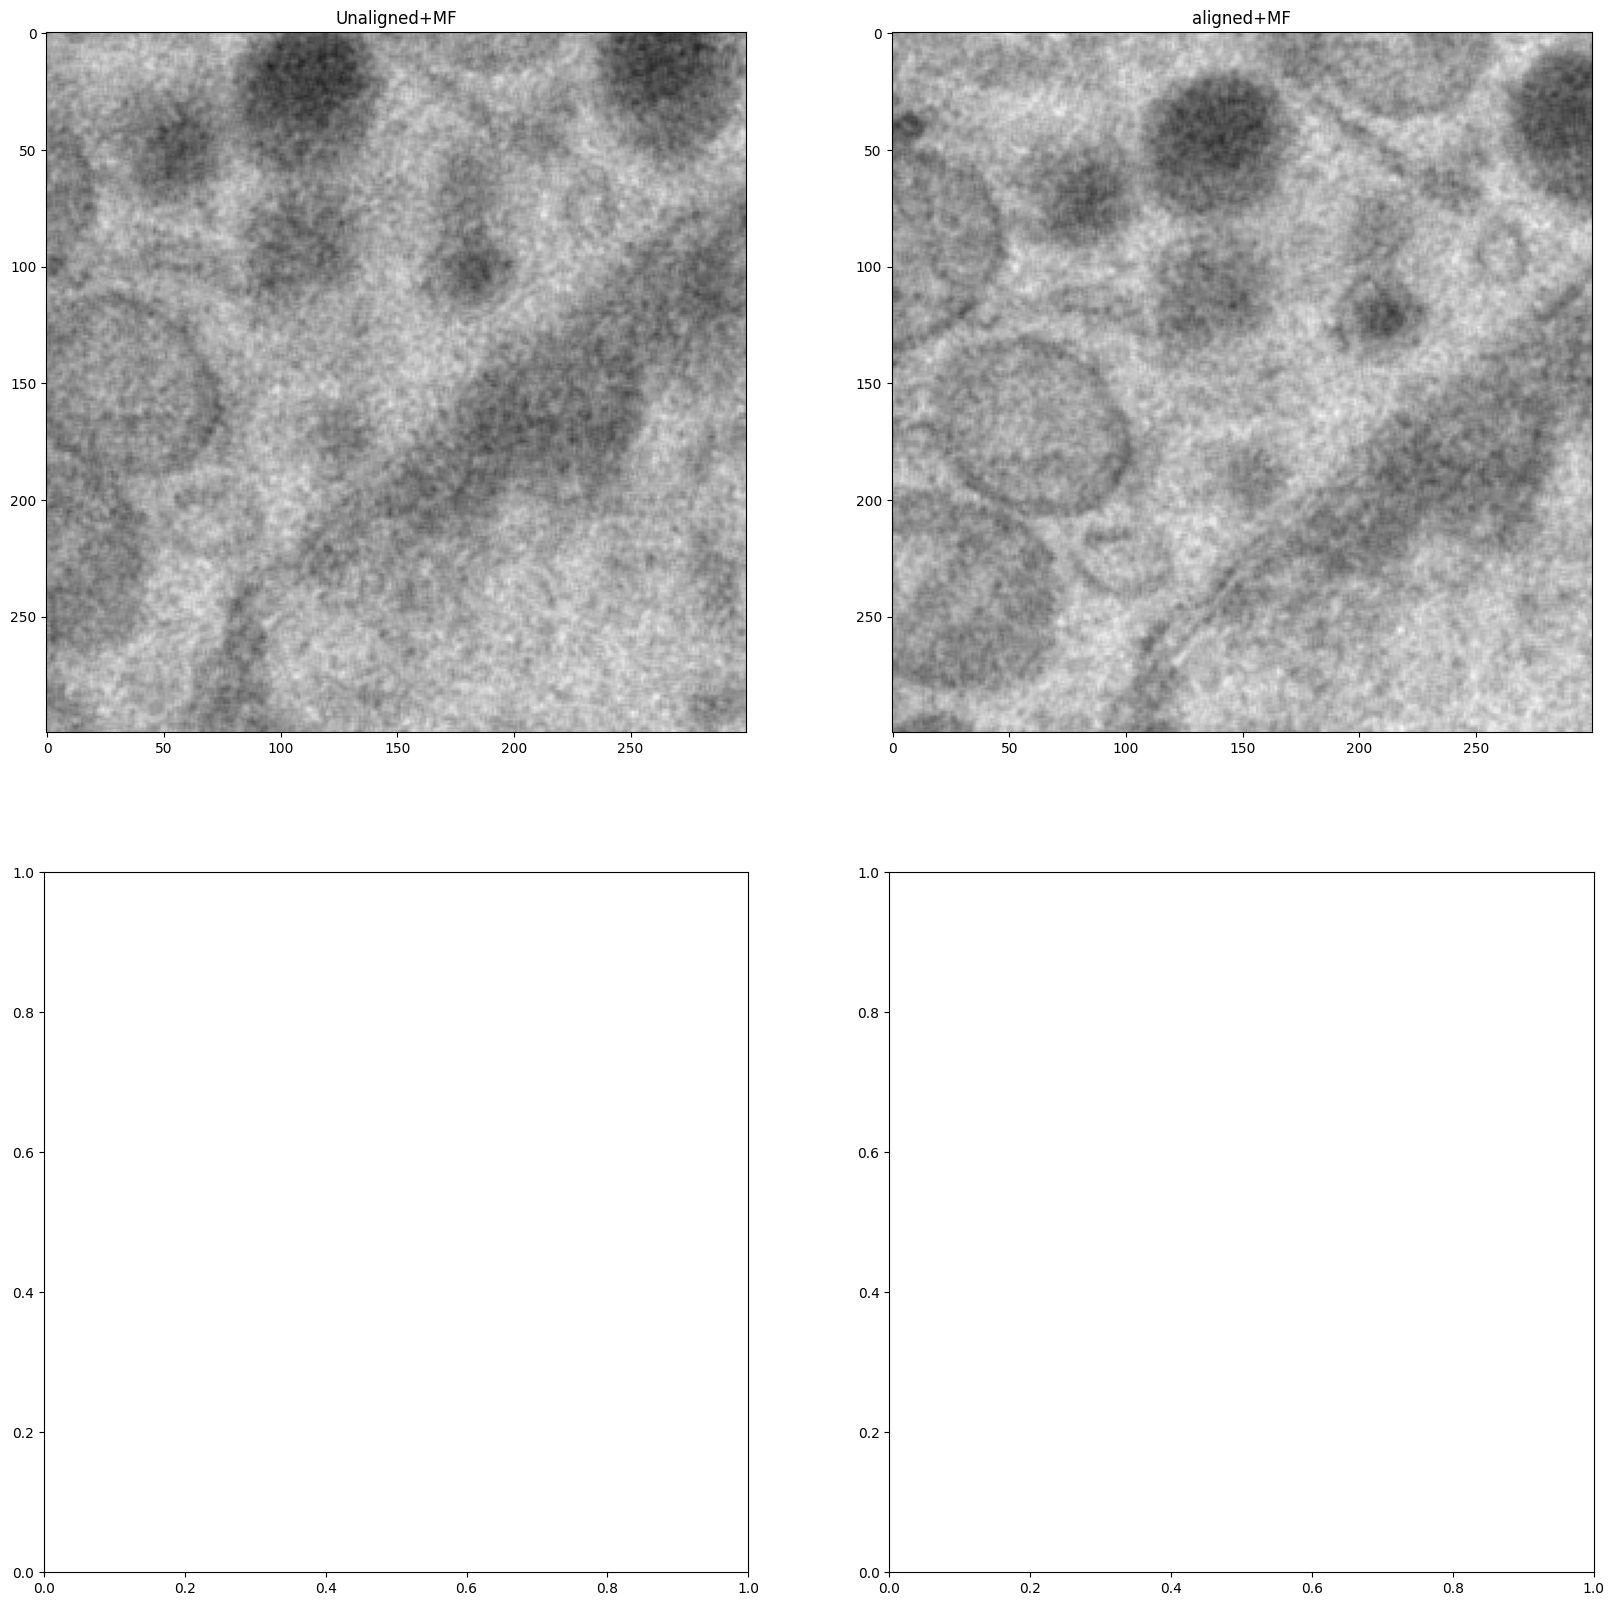

In [53]:
bands = [3,3,3]
f, ax = plt.subplots(2,2,figsize=(20,20))
#x1,x2,y1,y2 = [200,450,150,400]
x1,x2,y1,y2 = [600,900,600,900]

#ax[0][0].imshow(tile_1.FalseColor(bands)[x1:x2,y1:y2,:])
ax[0][0].imshow(tile_1.FalseColor(bands)[pad_remove:2048-pad_remove,pad_remove:2048-pad_remove,:][x1:x2,y1:y2,:])

ax[0][1].imshow(tile_2.FalseColor(bands)[x1:x2,y1:y2,:])



#ax[1][0].imshow(tile_3.FalseColor(bands)[pad_remove:2048-pad_remove,pad_remove:2048-pad_remove,:][x1:x2,y1:y2,:])
#ax[1][1].imshow(tile_4.FalseColor(bands)[x1:x2,y1:y2,:])

ax[0][0].set_title('Unaligned+MF')
ax[0][1].set_title('aligned+MF')
#ax[1][0].set_title('Unaligned+MF+denoise')
#ax[1][1].set_title('aligned+MF+denoise')
#ax[1].axis('off')